In [21]:
import pandas as pd
import numpy as np
from pathlib import Path

PROCESSED_DIR = Path("../data/processed")
post_path = PROCESSED_DIR / "post_features.parquet"
author_path = PROCESSED_DIR / "author_features.parquet"
dup_path = PROCESSED_DIR / "dup_lookup.parquet"
kw_path = PROCESSED_DIR / "kw_lookup.parquet"

print("--- DOSYA KONTROLÜ ---")
for p in [post_path, author_path, dup_path, kw_path]:
    if p.exists():
        size_mb = p.stat().st_size / (1024 * 1024)
        print(f"{p.name} ({size_mb:.2f} MB)")
    else:
        print(f"{p.name} — YOK!")

--- DOSYA KONTROLÜ ---
post_features.parquet (177.06 MB)
author_features.parquet (66.62 MB)
dup_lookup.parquet (0.63 MB)
kw_lookup.parquet (1.18 MB)


## 1. Veri Yükleme & Sütun Kontrolü

In [22]:
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")

post_df   = pd.read_parquet(post_path)
author_df = pd.read_parquet(author_path)
dup_df    = pd.read_parquet(dup_path)
kw_df     = pd.read_parquet(kw_path)

FEATURE_COLS = [
    "text_len", "kw_count", "kw_density",
    "sentiment", "sentiment_extreme", "is_duplicate", "has_author",
    "cross_author_dup_count", "kw_fingerprint_shared",
    "author_posts_per_day", "author_min_interval_sec",
    "author_mean_jaccard",
    "author_sentiment_std", "author_unique_themes", "author_duplicate_ratio"
]

POST_FEAT   = FEATURE_COLS[:9]
AUTHOR_FEAT = FEATURE_COLS[9:]

feat_df = post_df[FEATURE_COLS].copy()

print(f"post_features  : {post_df.shape[0]:,} satır × {post_df.shape[1]} sütun")
print(f"author_features: {author_df.shape[0]:,} yazar × {author_df.shape[1]} sütun")

missing_cols = [c for c in FEATURE_COLS if c not in post_df.columns]
print(f"\nEksik feature sütunları: {missing_cols if missing_cols else 'YOK — tüm 15 feature mevcut ✓'}")

print("\nDtype'lar:")
display(feat_df.dtypes.rename("dtype").to_frame())

post_features  : 5,004,813 satır × 21 sütun
author_features: 1,597,836 yazar × 7 sütun

Eksik feature sütunları: YOK — tüm 15 feature mevcut ✓

Dtype'lar:


,dtype
text_len,int64
kw_count,int64
kw_density,float64
sentiment,float32
sentiment_extreme,int64
is_duplicate,int64
has_author,int64
cross_author_dup_count,int64
kw_fingerprint_shared,int64
author_posts_per_day,float64


In [23]:
import pyarrow.parquet as pq
from pathlib import Path

try:
    parquet_file = pq.ParquetFile(post_path)
    columns = parquet_file.schema.names
    feature_count = len(columns)

    print(f"Total number of features: {feature_count}\n")
    print("Feature names (Keys):")
    for col in columns:
        print(f" - {col}")

except FileNotFoundError:
    print(f"Error: The file could not be found at {post_path}")
except Exception as e:
    print(f"An unexpected error occurred: {e}")

Total number of features: 21

Feature names (Keys):
 - sentiment
 - main_emotion
 - primary_theme
 - language
 - author_hash
 - timestamp
 - domain
 - has_author
 - text_len
 - kw_count
 - kw_density
 - sentiment_extreme
 - cross_author_dup_count
 - kw_fingerprint_shared
 - is_duplicate
 - author_posts_per_day
 - author_min_interval_sec
 - author_sentiment_std
 - author_unique_themes
 - author_duplicate_ratio
 - author_mean_jaccard


## 2. Temel İstatistikler

In [4]:
print("=== POST-LEVEL FEATURES (10) ===")
display(feat_df[POST_FEAT].describe().round(4))

print("\n=== AUTHOR-LEVEL FEATURES (7) ===")
display(feat_df[AUTHOR_FEAT].describe().round(4))

=== POST-LEVEL FEATURES (10) ===


,text_len,kw_count,kw_density,sentiment,sentiment_extreme,is_duplicate,has_author,cross_author_dup_count,kw_fingerprint_shared
count,5.004813e+06,5.004813e+06,5.004813e+06,5.004813e+06,5.004813e+06,5.004813e+06,5.004813e+06,5.004813e+06,5.004813e+06
mean,1.451410e+02,1.260490e+01,1.070000e-01,1.780000e-02,3.160000e-02,2.140000e-02,5.679000e-01,7.147000e-01,4.556900e+00
std,1.692286e+02,1.084050e+01,7.540000e-02,4.107000e-01,1.750000e-01,1.449000e-01,4.954000e-01,1.320610e+01,5.091560e+01
min,0.000000e+00,0.000000e+00,0.000000e+00,-9.800000e-01,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
25%,4.900000e+01,5.000000e+00,7.250000e-02,-2.700000e-01,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
50%,9.900000e+01,1.000000e+01,9.380000e-02,2.000000e-02,0.000000e+00,0.000000e+00,1.000000e+00,0.000000e+00,0.000000e+00
75%,1.970000e+02,1.800000e+01,1.250000e-01,2.800000e-01,0.000000e+00,0.000000e+00,1.000000e+00,0.000000e+00,0.000000e+00
max,2.529000e+03,1.140000e+03,2.057140e+01,9.900000e-01,1.000000e+00,1.000000e+00,1.000000e+00,5.710000e+02,1.410000e+03



=== AUTHOR-LEVEL FEATURES (7) ===


,author_posts_per_day,author_min_interval_sec,author_mean_jaccard,author_sentiment_std,author_unique_themes,author_duplicate_ratio
count,5.004813e+06,5.004813e+06,5.004813e+06,5.004813e+06,5.004813e+06,5.004813e+06
mean,3.702670e+01,7.496108e+04,1.490000e-02,1.075000e-01,2.197400e+00,1.750000e-02
std,3.071943e+02,8.146553e+04,7.820000e-02,1.824000e-01,2.984600e+00,1.093000e-01
min,1.817000e-01,0.000000e+00,0.000000e+00,0.000000e+00,1.000000e+00,0.000000e+00
25%,1.000000e+00,3.036000e+03,0.000000e+00,0.000000e+00,1.000000e+00,0.000000e+00
50%,1.000000e+00,8.640000e+04,0.000000e+00,0.000000e+00,1.000000e+00,0.000000e+00
75%,1.000000e+00,8.640000e+04,0.000000e+00,1.937000e-01,2.000000e+00,0.000000e+00
max,3.205151e+03,8.646000e+05,1.000000e+00,1.301100e+00,1.500000e+01,1.000000e+00


## 3. Eksik Değer Analizi

In [5]:
null_counts = feat_df[FEATURE_COLS].isnull().sum()
null_pct    = (null_counts / len(feat_df) * 100).round(3)
null_summary = pd.DataFrame({"null_count": null_counts, "null_pct_%": null_pct})

null_cols = null_summary[null_summary["null_count"] > 0]
if null_cols.empty:
    print("Hiç eksik değer yok ✓")
else:
    print(f"{len(null_cols)} feature'da eksik değer var:")
    display(null_cols.sort_values("null_count", ascending=False))

Hiç eksik değer yok ✓


## 4. Korelasyon Analizi

### 4a. Pearson Korelasyon Matrisi (Heatmap)

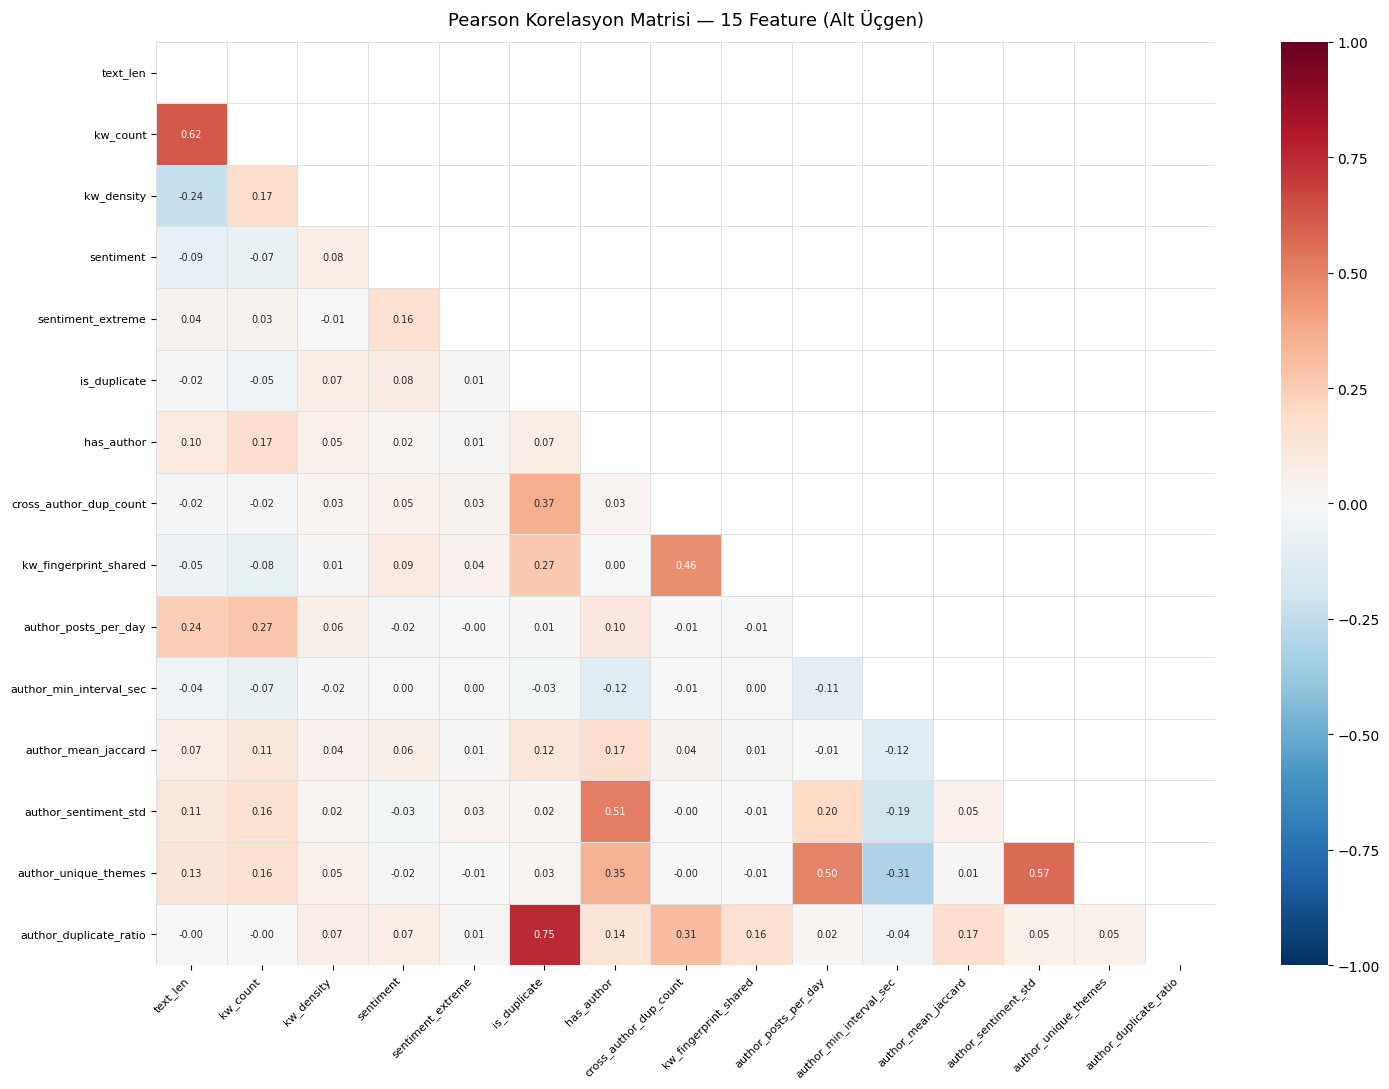

In [7]:
corr = feat_df[FEATURE_COLS].corr(method="pearson")

fig, ax = plt.subplots(figsize=(15, 11))
mask = np.triu(np.ones_like(corr, dtype=bool))  # üst üçgeni maskele
sns.heatmap(
    corr,
    mask=mask,
    annot=True, fmt=".2f", center=0,
    cmap="RdBu_r", vmin=-1, vmax=1,
    linewidths=0.4, linecolor="#e0e0e0",
    annot_kws={"size": 7},
    ax=ax
)
ax.set_title("Pearson Korelasyon Matrisi — 15 Feature (Alt Üçgen)", fontsize=13, pad=12)
plt.xticks(rotation=45, ha="right", fontsize=8)
plt.yticks(fontsize=8)
plt.tight_layout()
plt.show()

### 4b. Yüksek |Pearson| Çiftleri (eşik > 0.80)

In [8]:
THRESH = 0.80

pairs = []
for i, c1 in enumerate(FEATURE_COLS):
    for j, c2 in enumerate(FEATURE_COLS):
        if j <= i:
            continue
        val = corr.loc[c1, c2]
        if abs(val) > THRESH:
            pairs.append({"feature_A": c1, "feature_B": c2, "pearson": round(val, 4)})

if pairs:
    high_corr = pd.DataFrame(pairs).sort_values("pearson", key=abs, ascending=False)
    print(f"⚠  |Pearson| > {THRESH} olan çiftler ({len(high_corr)} adet):")
    display(high_corr)
    print("\nBu feature çiftleri çakışma riski taşır — modelde birini drop etmeyi veya PCA'yı değerlendir.")
else:
    print(f"✓  |Pearson| > {THRESH} olan çift yok — multicollinearity riski düşük.")

✓  |Pearson| > 0.8 olan çift yok — multicollinearity riski düşük.


## 5. VIF (Variance Inflation Factor) Analizi

VIF > 10 → ciddi çoklu doğrusallık riski; 5–10 → orta; < 5 → güvenli.

In [9]:
from statsmodels.stats.outliers_influence import variance_inflation_factor

vif_df = feat_df[FEATURE_COLS].replace([np.inf, -np.inf], np.nan).dropna()
print(f"VIF hesabı için kullanılan satır sayısı: {len(vif_df):,} ({len(vif_df)/len(feat_df)*100:.1f}%)")

vif_values = [
    variance_inflation_factor(vif_df.values, i)
    for i in range(len(FEATURE_COLS))
]

vif_data = pd.DataFrame({"feature": FEATURE_COLS, "VIF": vif_values})
vif_data["VIF"] = vif_data["VIF"].round(2)
vif_data["status"] = vif_data["VIF"].apply(
    lambda v: "🔴 YÜKSEK (>10)" if v > 10 else ("🟡 ORTA (5–10)" if v > 5 else "🟢 OK (<5)")
)
vif_data = vif_data.sort_values("VIF", ascending=False).reset_index(drop=True)

display(vif_data)
print(f"\nVIF > 10: {(vif_data['VIF'] > 10).sum()} feature")
print(f"VIF 5–10: {((vif_data['VIF'] > 5) & (vif_data['VIF'] <= 10)).sum()} feature")
print(f"VIF < 5 : {(vif_data['VIF'] <= 5).sum()} feature")

VIF hesabı için kullanılan satır sayısı: 5,004,813 (100.0%)


,feature,VIF,status
0,kw_count,4.89,🟢 OK (<5)
1,text_len,3.26,🟢 OK (<5)
2,has_author,3.06,🟢 OK (<5)
3,author_unique_themes,2.94,🟢 OK (<5)
4,kw_density,2.83,🟢 OK (<5)
5,is_duplicate,2.52,🟢 OK (<5)
6,author_duplicate_ratio,2.43,🟢 OK (<5)
7,author_sentiment_std,2.42,🟢 OK (<5)
8,author_min_interval_sec,1.64,🟢 OK (<5)
9,author_posts_per_day,1.41,🟢 OK (<5)



VIF > 10: 0 feature
VIF 5–10: 0 feature
VIF < 5 : 15 feature


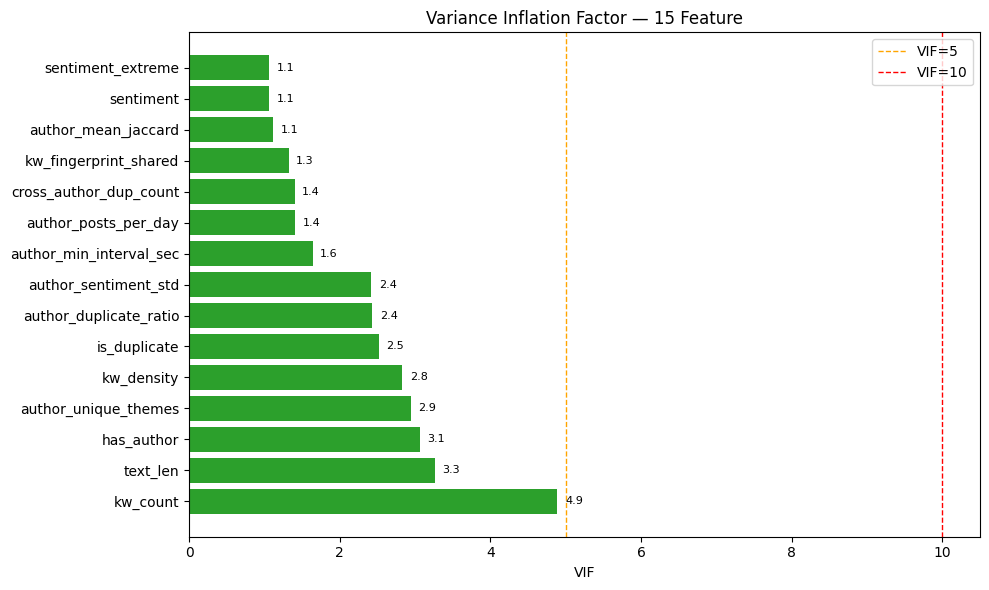

In [15]:
fig, ax = plt.subplots(figsize=(10, 6))
colors = ["#d62728" if v > 10 else "#ff7f0e" if v > 5 else "#2ca02c" for v in vif_data["VIF"]]
bars = ax.barh(vif_data["feature"], vif_data["VIF"], color=colors)
ax.axvline(x=5,  color="orange", linestyle="--", linewidth=1, label="VIF=5")
ax.axvline(x=10, color="red",    linestyle="--", linewidth=1, label="VIF=10")
ax.set_xlabel("VIF")
ax.set_title("Variance Inflation Factor — 15 Feature")
ax.legend()
for bar, val in zip(bars, vif_data["VIF"]):
    ax.text(bar.get_width() + 0.1, bar.get_y() + bar.get_height()/2,
            f"{val:.1f}", va="center", fontsize=8)
plt.tight_layout()
plt.show()

## 6. Feature Dağılımları

### 6a. Post-Level (10 Feature)

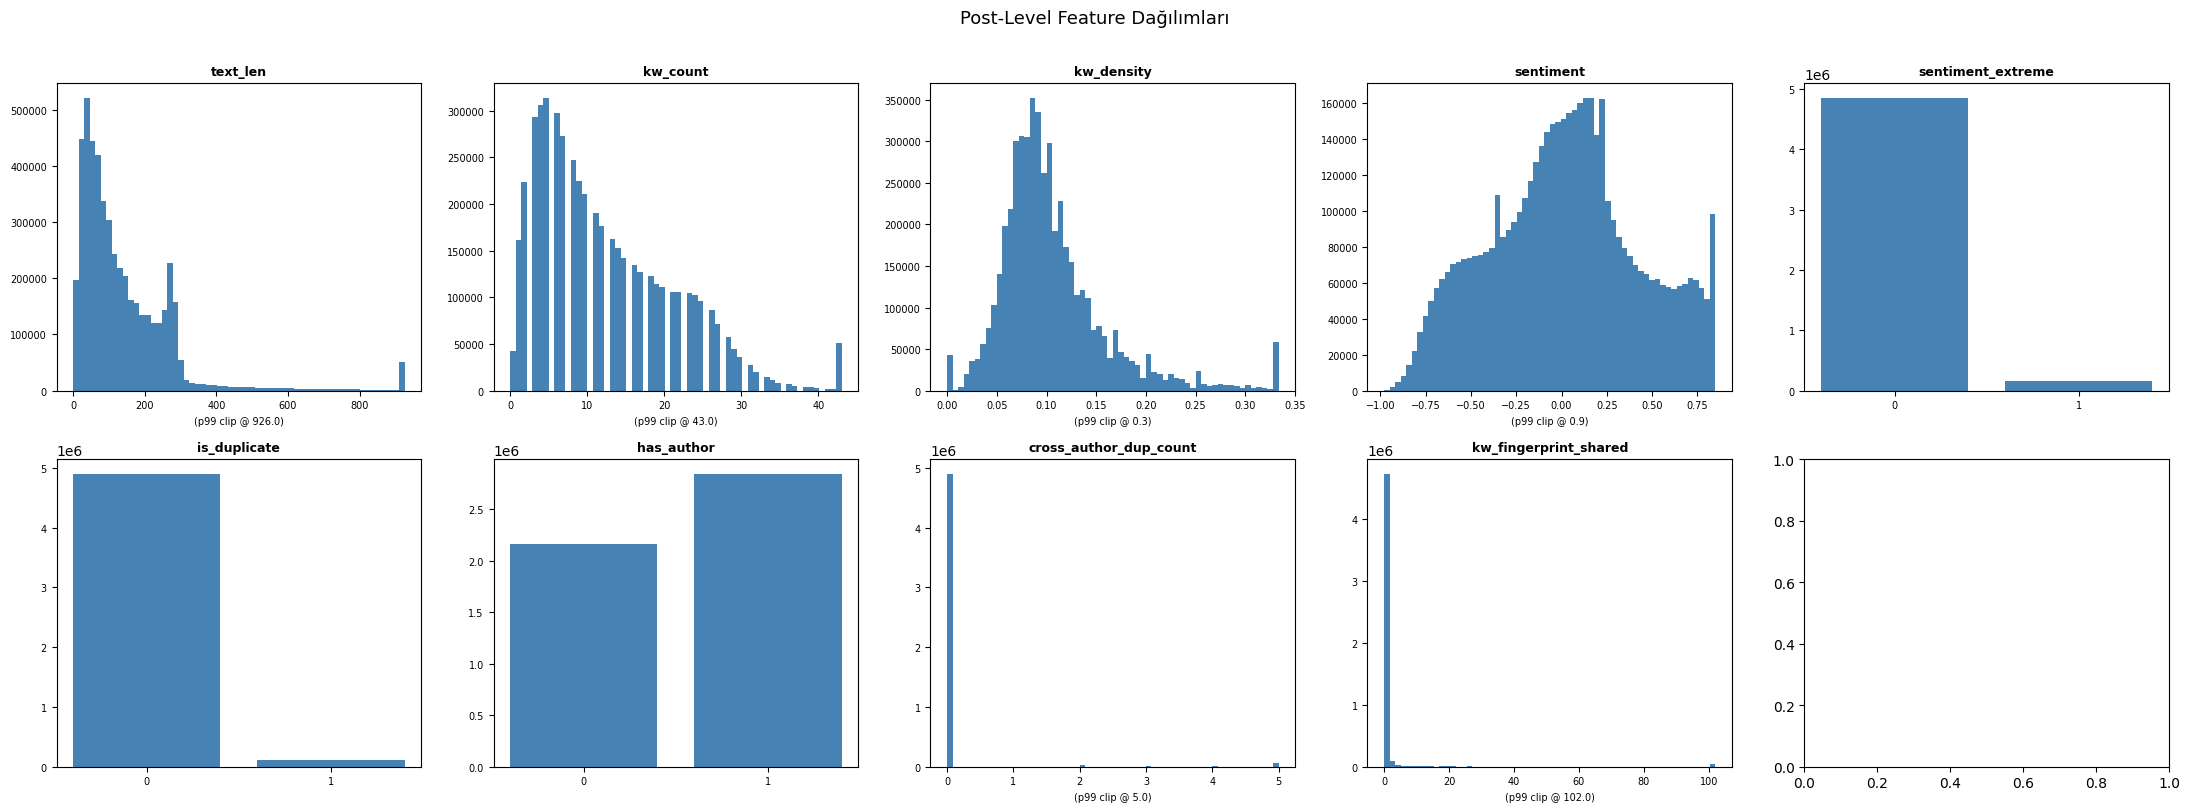

In [11]:
fig, axes = plt.subplots(2, 5, figsize=(22, 8))
axes = axes.flatten()

for i, col in enumerate(POST_FEAT):
    data = feat_df[col].dropna()
    if data.nunique() <= 3:
        vc = data.value_counts().sort_index()
        axes[i].bar([str(k) for k in vc.index], vc.values, color="steelblue")
        axes[i].set_xticks(range(len(vc)))
        axes[i].set_xticklabels([str(k) for k in vc.index])
    else:
        clip_val = data.quantile(0.99)
        axes[i].hist(data.clip(upper=clip_val), bins=60, color="steelblue", edgecolor="none")
        axes[i].set_xlabel(f"(p99 clip @ {clip_val:.1f})", fontsize=7)
    axes[i].set_title(col, fontsize=9, fontweight="bold")
    axes[i].tick_params(labelsize=7)

plt.suptitle("Post-Level Feature Dağılımları", fontsize=13, y=1.01)
plt.tight_layout()
plt.show()

### 6b. Author-Level (6 Feature)

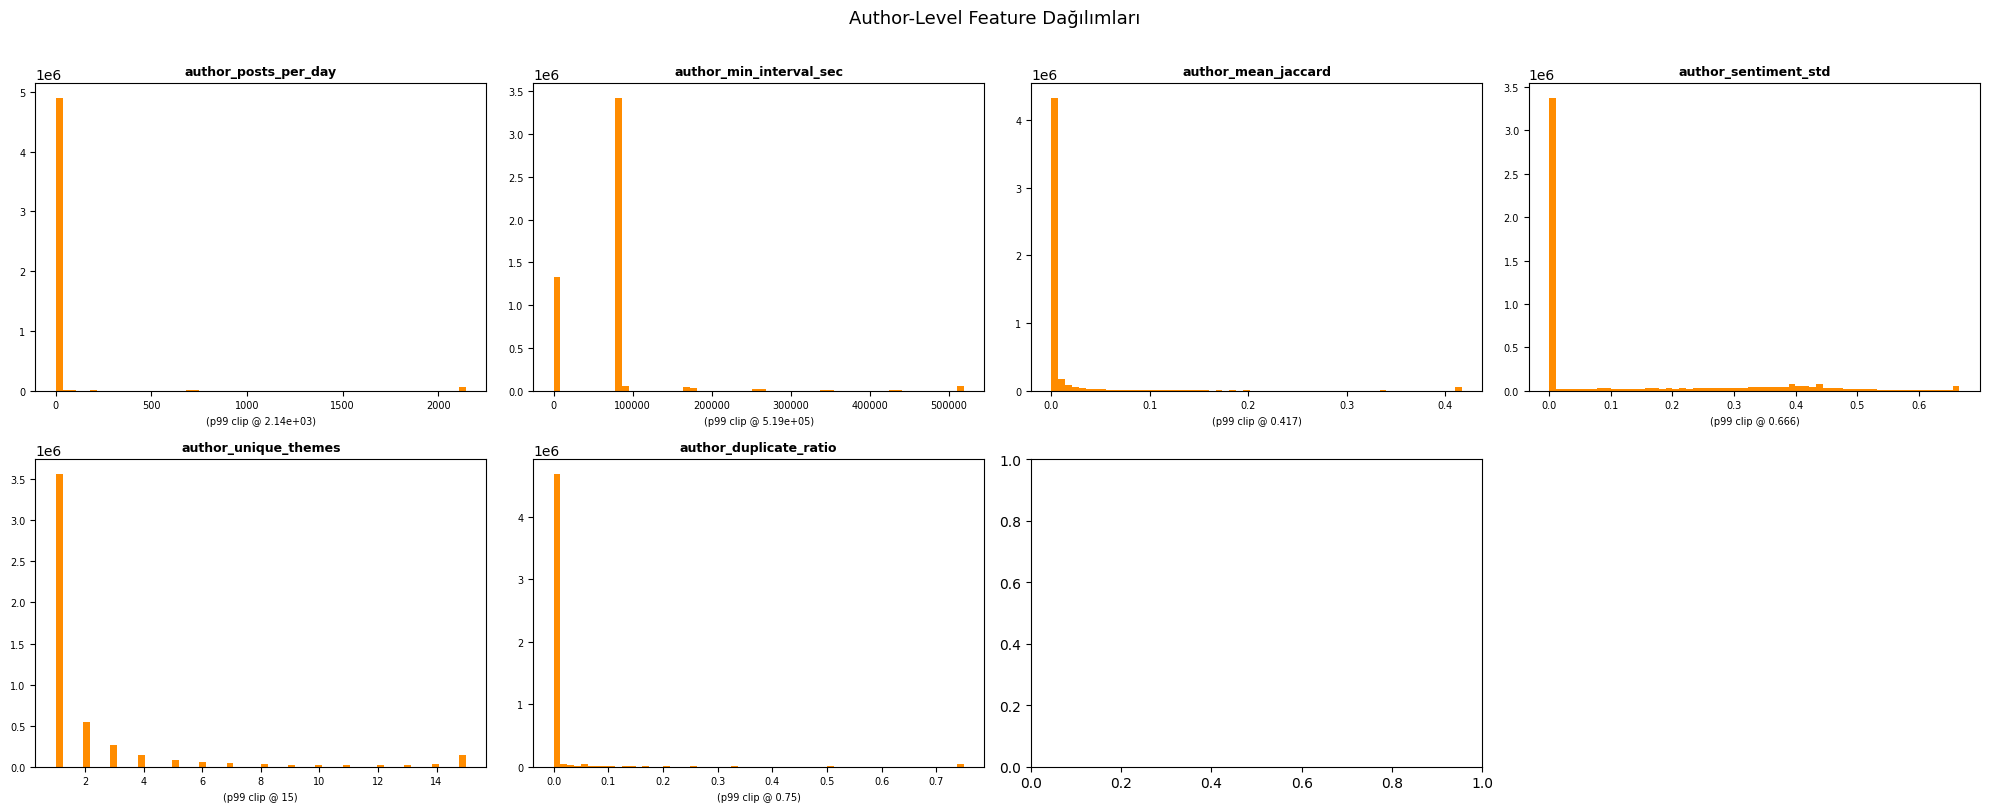

In [16]:
fig, axes = plt.subplots(2, 4, figsize=(20, 8))
axes = axes.flatten()

for i, col in enumerate(AUTHOR_FEAT):
    data = feat_df[col].dropna()
    clip_val = data.quantile(0.99)
    axes[i].hist(data.clip(upper=clip_val), bins=60, color="darkorange", edgecolor="none")
    axes[i].set_title(col, fontsize=9, fontweight="bold")
    axes[i].set_xlabel(f"(p99 clip @ {clip_val:.3g})", fontsize=7)
    axes[i].tick_params(labelsize=7)

axes[-1].set_visible(False)

plt.suptitle("Author-Level Feature Dağılımları", fontsize=13, y=1.01)
plt.tight_layout()
plt.show()

## 7. Binary Feature Dağılımları

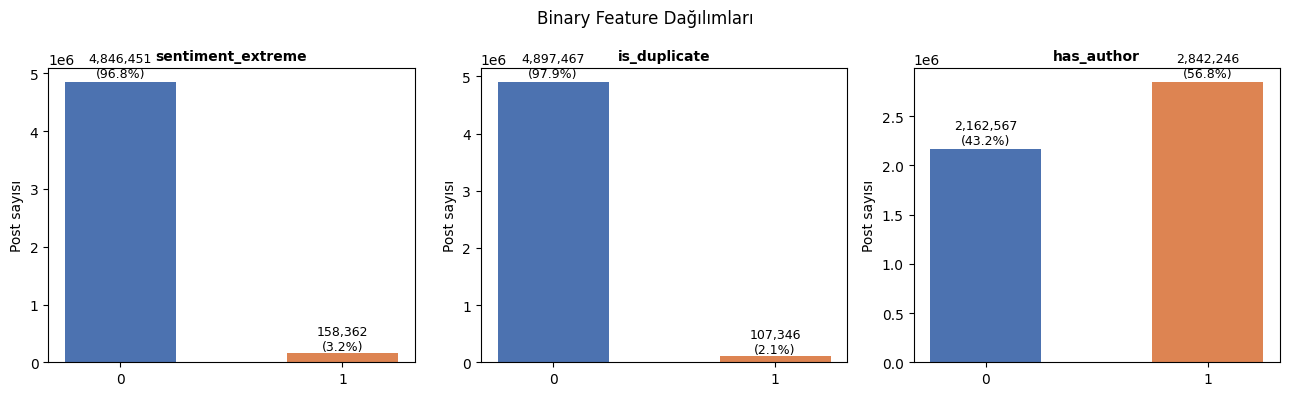

In [17]:
binary_cols = ["sentiment_extreme", "is_duplicate", "has_author"]
fig, axes = plt.subplots(1, 3, figsize=(13, 4))

for i, col in enumerate(binary_cols):
    vc = feat_df[col].value_counts().sort_index()
    bars = axes[i].bar(["0", "1"], vc.values, color=["#4C72B0", "#DD8452"], width=0.5)
    axes[i].set_title(col, fontsize=10, fontweight="bold")
    axes[i].set_ylabel("Post sayısı")
    for bar, val in zip(bars, vc.values):
        axes[i].text(
            bar.get_x() + bar.get_width() / 2, bar.get_height() * 1.01,
            f"{val:,}\n({val/len(feat_df)*100:.1f}%)",
            ha="center", va="bottom", fontsize=9
        )

plt.suptitle("Binary Feature Dağılımları", fontsize=12)
plt.tight_layout()
plt.show()

## 8. Outlier Analizi (3×IQR kuralı)

In [18]:
Q1  = feat_df[FEATURE_COLS].quantile(0.25)
Q3  = feat_df[FEATURE_COLS].quantile(0.75)
IQR = Q3 - Q1
lower = Q1 - 3 * IQR
upper = Q3 + 3 * IQR

is_outlier = (feat_df[FEATURE_COLS] < lower) | (feat_df[FEATURE_COLS] > upper)
outlier_pct = (is_outlier.sum() / len(feat_df) * 100).round(3)

outlier_summary = pd.DataFrame({
    "p1"             : feat_df[FEATURE_COLS].quantile(0.01).round(4),
    "p25"            : Q1.round(4),
    "median"         : feat_df[FEATURE_COLS].median().round(4),
    "p75"            : Q3.round(4),
    "p99"            : feat_df[FEATURE_COLS].quantile(0.99).round(4),
    "max"            : feat_df[FEATURE_COLS].max().round(4),
    "outlier_%_3IQR" : outlier_pct,
})

display(outlier_summary.sort_values("outlier_%_3IQR", ascending=False))
print(f"\n3×IQR dışında en az 1 post: {is_outlier.any(axis=1).sum():,} satır ({is_outlier.any(axis=1).mean()*100:.2f}%)")

,p1,p25,median,p75,p99,max,outlier_%_3IQR
author_posts_per_day,0.2851,1.0000,1.0000,1.0000,2144.2150,3205.1515,33.378
author_mean_jaccard,0.0000,0.0000,0.0000,0.0000,0.4167,1.0000,20.952
author_unique_themes,1.0000,1.0000,1.0000,2.0000,15.0000,15.0000,8.093
author_duplicate_ratio,0.0000,0.0000,0.0000,0.0000,0.7500,1.0000,7.286
kw_fingerprint_shared,0.0000,0.0000,0.0000,0.0000,102.0000,1410.0000,5.528
sentiment_extreme,0.0000,0.0000,0.0000,0.0000,1.0000,1.0000,3.164
is_duplicate,0.0000,0.0000,0.0000,0.0000,1.0000,1.0000,2.145
cross_author_dup_count,0.0000,0.0000,0.0000,0.0000,5.0000,571.0000,2.145
text_len,6.0000,49.0000,99.0000,197.0000,926.0000,2529.0000,1.942
author_min_interval_sec,0.0000,3036.0000,86400.0000,86400.0000,518864.0000,864600.0000,1.889



3×IQR dışında en az 1 post: 2,038,226 satır (40.73%)


## 9. Sanity Check — Formül Doğrulamaları

In [19]:
checks = []

# 1. kw_density = kw_count / (text_len + 1)
computed = feat_df["kw_count"] / (feat_df["text_len"] + 1)
delta = (feat_df["kw_density"] - computed).abs().max()
checks.append(("kw_density = kw_count / (text_len + 1)", delta < 1e-6, f"max_delta={delta:.2e}"))

# 2. is_duplicate = cross_author_dup_count > 0
computed2 = (feat_df["cross_author_dup_count"] > 0).astype(int)
match2 = (feat_df["is_duplicate"] == computed2).all()
checks.append(("is_duplicate ↔ cross_author_dup_count > 0", match2, ""))

# 3. sentiment ∈ [-1, 1]
s_min, s_max = feat_df["sentiment"].min(), feat_df["sentiment"].max()
checks.append(("sentiment ∈ [-1, 1]", s_min >= -1 and s_max <= 1, f"min={s_min:.4f}, max={s_max:.4f}"))

# 4. has_author ∈ {0, 1}
ha_vals = set(feat_df["has_author"].unique())
checks.append(("has_author ∈ {0, 1}", ha_vals.issubset({0, 1}), f"unique values: {sorted(ha_vals)}"))

# 5. author_duplicate_ratio ∈ [0, 1]
dr_min, dr_max = feat_df["author_duplicate_ratio"].min(), feat_df["author_duplicate_ratio"].max()
checks.append(("author_duplicate_ratio ∈ [0, 1]", 0 <= dr_min and dr_max <= 1, f"min={dr_min:.4f}, max={dr_max:.4f}"))

# 6. author_mean_jaccard ∈ [0, 1]
mj_min, mj_max = feat_df["author_mean_jaccard"].min(), feat_df["author_mean_jaccard"].max()
checks.append(("author_mean_jaccard ∈ [0, 1]", 0 <= mj_min and mj_max <= 1, f"min={mj_min:.4f}, max={mj_max:.4f}"))

# 7. author_posts_per_day > 0
ppd_min = feat_df["author_posts_per_day"].min()
checks.append(("author_posts_per_day > 0", ppd_min > 0, f"min={ppd_min:.6f}"))

# 8. text_len >= 0
tl_min = feat_df["text_len"].min()
checks.append(("text_len >= 0", tl_min >= 0, f"min={tl_min}"))

print("=" * 65)
print("  SANITY CHECK SONUÇLARI")
print("=" * 65)
all_pass = True
for name, ok, detail in checks:
    icon = "✓" if ok else "✗"
    suffix = f"  [{detail}]" if detail else ""
    print(f"  {icon}  {name}{suffix}")
    if not ok:
        all_pass = False

print("=" * 65)
print(f"  {'Tüm kontroller geçti ✓' if all_pass else 'BAZI KONTROLLER BAŞARISIZ ✗'}")
print("=" * 65)

  SANITY CHECK SONUÇLARI
  ✓  kw_density = kw_count / (text_len + 1)  [max_delta=0.00e+00]
  ✓  is_duplicate ↔ cross_author_dup_count > 0
  ✓  sentiment ∈ [-1, 1]  [min=-0.9800, max=0.9900]
  ✓  has_author ∈ {0, 1}  [unique values: [np.int64(0), np.int64(1)]]
  ✓  author_duplicate_ratio ∈ [0, 1]  [min=0.0000, max=1.0000]
  ✓  author_mean_jaccard ∈ [0, 1]  [min=0.0000, max=1.0000]
  ✓  author_posts_per_day > 0  [min=0.181703]
  ✓  text_len >= 0  [min=0]
  Tüm kontroller geçti ✓
